### This notebook compute "E1. Number of agricultural producers" indicator for the 27 basins of IKI Project

**Created:** 6/10/2025 by Jorge Mayo (jmayo@rti.org)  

**Project #:** 0219481  

**Last modified:** 1/2/2026 by Sophia (sbakar@rti.org)

**Status:** Copmlete for baseline and first future scenario.

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Exposicion\Scripts_Exposure
 
**Inputs:**   Perfil Productor Agropecuario (2012) (http://censos1.inei.gob.pe/Cenagro/redatam/#), Peru AHD with Districts

**Institutions** INEI

**Assumptions:** inherent assumptions in using weighted method to assign number of agricultural producers value for a particular COMID by weighting the values from each respective district within that COMID. 
 
**N/A Handling:** Skips over any empty cells and rows in agriculture producer dataset. Skips any invalid data in population dataset.

**Future work:** 
 
**Notes:**  
General Methodology:  
1. Determines the proportionate area of each district within each COMID.   
2. Extracts raw population data: Total number of male and female producers and total number of producers (male and female combined) per district.  
3. Uses proportionate values to determine the number of producers in each COMID (see _Assumptions_ above).


In [ ]:
## Steps for QC
# Verify that the first code cells follow this structure
# 1) import libraries
# 2) set up user and database path (this will eventually change based on how we set up the repo/distribute the input data)
# 3) set up indicator ID and get scenarios from the database - for now we are just populating the database for scenarios 1 and 2, but there should be commented lines to get all available scenarios from the database
# 4) define filepaths for input data (again this will eventually change so for now we want all the filepaths in one block to change later)

# Then verify that the rest of the code performs the intended calculations and outputs the expected results. You can run up until the sql insert which is the last three cells in the notebook.
# Make sure the code to perform the calculations is well-organized and commented for clarity.
# Add notes about the methodology, assumptions, and anything that sticks out about the results in the markdown block at the top of the page.
# Add any notes about NaN/0 handling in the markdown block under notes or assumptions
# Add a section in the markdown "QA performed by:" so that we know who checked and when 


In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'sgilson'
#user = 'nreynolds'
user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 201 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

#districts_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/GIS/5_ADMIN_BOUNDARIES_VIAS_ROADS_CIUDADES_CITIES/Limite_Demografico/Shp_Distritos_2021/ngeo_Distritos_2021.shp'
districts_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\GIS\5_ADMIN_BOUNDARIES_VIAS_ROADS_CIUDADES_CITIES\Limite_Demografico\Shp_Distritos_2021\ngeo_Distritos_2021.shp"

#inei_df_raw = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Exposicion\E1_Number of agricultural producers\Perfil_Productor_Agropecuario_2012.xlsx'
inei_df_raw = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Exposicion\E1_Number of agricultural producers\Perfil_Productor_Agropecuario_2012.xlsx"

#Define District_within_COMID fractions csv - this allows for a weighted method to be used for assigning district level data to subbasins
# district_area_within_COMID = frf'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/COMID_District_Fractions.csv'
district_area_within_COMID = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\COMID_District_Fractions.csv"

In [5]:
#read input files
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
districts_gdf = gpd.read_file(districts_shapefile).to_crs('EPSG:32718')
df_raw = pd.read_excel(inei_df_raw, header=None)
district_area_within_COMID= pd.read_csv(district_area_within_COMID)

In [6]:
#WEIGHTED METHOD FUNCTION 
# For each COMID, calculate proportionate lighting values based on district area fractions
#could amplify this fraction so it could read in any value by IDDIST 
def calculate_proportionate_values(district_fractions_df, value_df, column_name, comid_list):
    """
    Calculate proportionate values for each COMID based on district area fractions
    
    Parameters:
    - district_fractions_df: DataFrame with COMID, DISTRICT, district_area_within_COMID_fraction
    - value_df: DataFrame with IDDIST and indicator values
    - column_name: Name of the column containing the indicator values
    - comid_list: List of COMIDs to process
    
    Returns:
    - DataFrame with COMID and proportionate_indicator_value
    """
    # Ensure IDDIST and DISTRICT columns are in the same format
    value_df = value_df.copy()
    district_fractions_df = district_fractions_df.copy()
    
    value_df['IDDIST'] = value_df['IDDIST'].astype(str).str.strip()
    district_fractions_df['DISTRICT'] = district_fractions_df['DISTRICT'].astype(str).str.strip()
    
    results = []
    
    for comid in comid_list:
        districts_in_comid = district_fractions_df[
            district_fractions_df['COMID'] == comid
        ]
        
        total = 0.0
        found_any = False
        
        for _, row in districts_in_comid.iterrows():
            district_id = row['DISTRICT']
            fraction = row['district_area_within_COMID_fraction']
            
            ind_value = value_df.loc[
                value_df['IDDIST'] == district_id, column_name
            ]
            
            if not ind_value.empty:
                total += ind_value.iloc[0] * fraction
                found_any = True
        
        results.append({
            'COMID': comid,
            'proportionate_indicator_value': total if found_any else np.nan
        })
    
    return pd.DataFrame(results)

In [7]:
records = []

# Loop through rows to find and extract blocks of data
for i, row in df_raw.iterrows():
    # Read values from columns A and B
    col_a = str(row[0]) if pd.notnull(row[0]) else ""
    col_b = str(row[1]) if pd.notnull(row[1]) else ""

    # Detect start of a block by "AREA #"
    if col_a.startswith("AREA #") and "Dpto." in col_b:
        area_code = col_a.replace("AREA #", "").strip()
        
        # Extract Dpto, Prov, Dist from col_b
        dpto = col_b.split("Dpto.")[1].split("Prov.")[0].strip()
        prov = col_b.split("Prov.")[1].split("Dist.")[0].strip()
        dist = col_b.split("Dist.")[1].strip()

    # Detect totals row (row[0] == "Total" and has gender data)
    if isinstance(row[0], str) and row[0].strip().startswith("Total"):
        try:
            hombres = int(row[1])
            mujeres = int(row[2])
            total = int(row[3])
        except:
            continue  # skip rows with invalid data

        # Append cleaned row
        records.append({
            "IDDIST": area_code,
            "Dpto": dpto,
            "Prov": prov,
            "Dist": dist,
            "Total_Hombres": hombres,
            "Total_Mujeres": mujeres,
            "Total": total
        })

# Final clean DataFrame
df_clean = pd.DataFrame(records)

In [8]:
# WEIGHTED METHOD: Calculate proportionate values based on district area fractions within each COMID

# Prepare district data - rename AREA to IDDIST for consistency with the weighted function
df_clean_weighted = df_clean.copy()

# Get list of all COMIDs
comid_list = subbasins_gdf['COMID'].unique().tolist()

# Calculate proportionate values using weighted method
weighted_results = calculate_proportionate_values(
    district_fractions_df=district_area_within_COMID,
    value_df=df_clean_weighted,
    column_name='Total',
    comid_list=comid_list
)

# Merge weighted results back to subbasins
subbasins_with_total = subbasins_gdf.merge(
    weighted_results,
    on='COMID',
    how='left'
)

# Rename the proportionate value column for clarity
subbasins_with_total = subbasins_with_total.rename(columns={'proportionate_indicator_value': 'Total'})

# Round to 2 decimal places
subbasins_with_total['Total'] = subbasins_with_total['Total'].round(2)

print(f"Weighted method applied. Total COMIDs: {len(subbasins_with_total)}")
print(f"\nSummary statistics for Total:")
print(subbasins_with_total['Total'].describe())

Weighted method applied. Total COMIDs: 3655

Summary statistics for Total:
count    2027.000000
mean      261.338096
std       479.912525
min         0.000000
25%        11.195000
50%        85.020000
75%       294.075000
max      4937.920000
Name: Total, dtype: float64


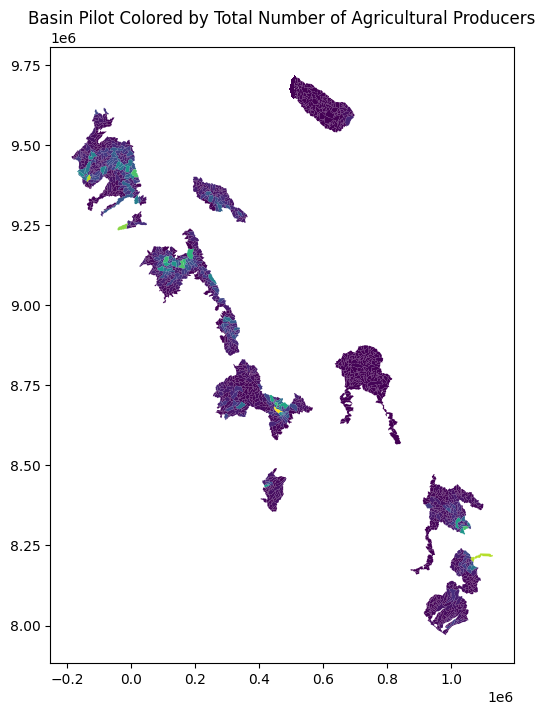

In [9]:
subbasins_with_total.plot(column='Total', legend=False, figsize=(10, 8))
plt.title('Basin Pilot Colored by Total Number of Agricultural Producers')
plt.show()

In [10]:
insert_data= subbasins_with_total #COMID 
value_column= 'Total' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [11]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_with_total['Total']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 201  Min: 0, Max: 10000000

=== Values to be inserted (by scenario) ===
   index    Total
0    min     0.00
1    max  4937.92
2  count  2027.00
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [12]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()